<a href="https://colab.research.google.com/github/bisenaditya21/Google-AI-Training-Programs-II/blob/main/newnotebookgoogleai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9261 - loss: 0.2430 - val_accuracy: 0.9792 - val_loss: 0.0633
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9685 - loss: 0.1033 - val_accuracy: 0.9840 - val_loss: 0.0505
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9765 - loss: 0.0776 - val_accuracy: 0.9841 - val_loss: 0.0472
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9808 - loss: 0.0634 - val_accuracy: 0.9857 - val_loss: 0.0427
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9830 - loss: 0.0529 - val_accuracy: 0.9862 - val_loss: 0.0417
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9857 - loss: 0.0451 - val_accuracy: 0.9883 - val_loss: 0.0403
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9872 - loss: 0.0406 - val_accuracy: 0.9877 - val_loss: 0.0424
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9884 - loss: 0.0350 -

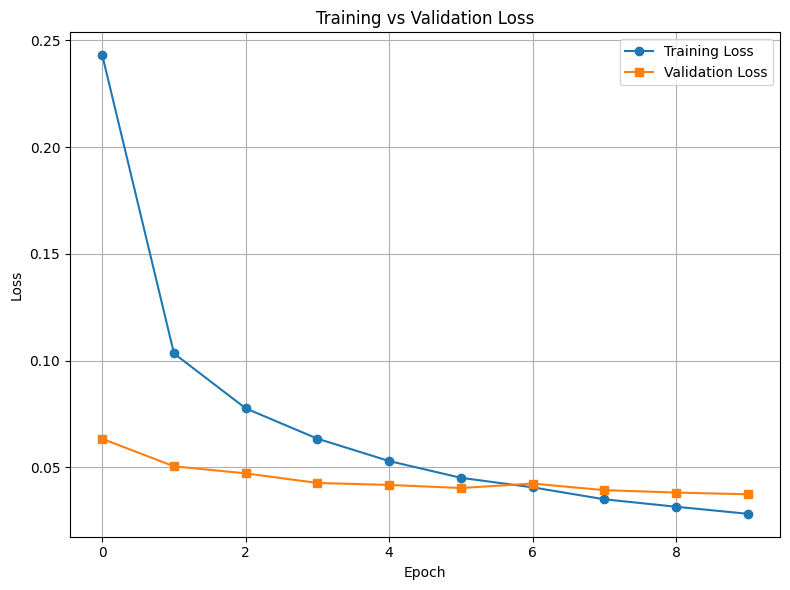

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train=x_train.reshape(-1,28,28,1).astype('float32')/255.0
x_test=x_test.reshape(-1,28,28,1).astype('float32')/255.0
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

#Build a simple CNN model
model=tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10,activation='softmax')
])

#Compile the model
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

#Train the model
history=model.fit(x_train,y_train,epochs=10,batch_size=32,validation_data=(x_test,y_test))

#Plot training vs validation loss
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'],label='Training Loss', marker='o')
plt.plot(history.history['val_loss'],label='Validation Loss', marker='s')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
#Cat vs Dog
#Step 1: Install Kaggle
!pip install -q kaggle

In [ ]:
#Step 2: Upload kaggle.json
from google.colab import files
files.upload()

In [ ]:
import os
import shutil

# Create the kaggle folder if it doesn't exist
os.makedirs('/root/.kaggle', exist_ok=True)

# Define source and destination paths
source_path = '/content/kaggle.json'
destination_dir = '/root/.kaggle'
destination_file_path = os.path.join(destination_dir, os.path.basename(source_path))

# Move kaggle.json only if it exists in /content and does not already exist in /root/.kaggle
if os.path.exists(source_path):
    if not os.path.exists(destination_file_path):
        shutil.move(source_path, destination_dir)
        print(f"'{source_path}' moved to '{destination_dir}'")
    else:
        print(f"'{destination_file_path}' already exists. Skipping move operation.")
        # Optional: if you want to ensure the file from /content is used, you could remove the old one first:
        # os.remove(destination_file_path)
        # shutil.move(source_path, destination_dir)
        # print(f"Existing '{destination_file_path}' overwritten and '{source_path}' moved.")
else:
    print(f"'{source_path}' does not exist. Please upload 'kaggle.json' first using the previous cell.")

In [ ]:
print("Kaggle API configured successfully")

In [ ]:
#Step 4: Download the Cats vs Dogs Dataset
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset


In [ ]:
import zipfile
import os
import shutil

zip_file_path = "microsoft-catsvsdogs-dataset.zip"
target_dir = "dataset"
temp_extract_dir = "temp_extracted_data"

# Clean up previous attempts and ensure target directory exists
if os.path.exists(target_dir):
    print(f"Removing existing '{target_dir}' directory.")
    shutil.rmtree(target_dir)
os.makedirs(target_dir, exist_ok=True)

if os.path.exists(temp_extract_dir):
    shutil.rmtree(temp_extract_dir)
os.makedirs(temp_extract_dir, exist_ok=True)

print(f"Extracting '{zip_file_path}' to '{temp_extract_dir}'...")
with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
    zip_ref.extractall(temp_extract_dir)
print("Extraction complete. Inspecting contents...")

# Find the PetImages directory within the extracted content
pet_images_source_path = None
for root, dirs, files in os.walk(temp_extract_dir):
    if "PetImages" in dirs:
        pet_images_source_path = os.path.join(root, "PetImages")
        break

if pet_images_source_path:
    destination_pet_images_path = os.path.join(target_dir, "PetImages")
    print(f"Found 'PetImages' at '{pet_images_source_path}'. Moving to '{destination_pet_images_path}'...")
    shutil.move(pet_images_source_path, destination_pet_images_path)
    print("PetImages moved successfully!")
else:
    print("Error: 'PetImages' directory not found within the extracted zip content.")
    print("Please check the structure of your zip file or manually locate 'PetImages'.")

# Clean up the temporary extraction directory
if os.path.exists(temp_extract_dir):
    print(f"Cleaning up temporary directory '{temp_extract_dir}'.")
    shutil.rmtree(temp_extract_dir)

print("Dataset extraction and setup complete!")


Removing existing 'dataset' directory.
Extracting 'microsoft-catsvsdogs-dataset.zip' to 'temp_extracted_data'...
Extraction complete. Inspecting contents...
Found 'PetImages' at 'temp_extracted_data/PetImages'. Moving to 'dataset/PetImages'...
PetImages moved successfully!
Cleaning up temporary directory 'temp_extracted_data'.
Dataset extraction and setup complete!


In [ ]:
import os
print(os.listdir("dataset"))
print(os.listdir("dataset/PetImages"))

['PetImages']
['Dog', 'Cat']


In [ ]:
#Step 7: Verify the number of images
print("cats:", len(os.listdir("dataset/PetImages/Cat")))
print("dogs:", len(os.listdir("dataset/PetImages/Dog")))

cats: 12501
dogs: 12501


In [ ]:
#Step 1: Split the dataset
import os
import shutil
import random

random.seed(42)

cat_source="dataset/PetImages/Cat"
dog_source="dataset/PetImages/Dog"

train_cat="dataset/train/cat"
train_dog="dataset/train/dog"
val_cat="dataset/validation/cat"
val_dog="dataset/validation/dog"

for folder in [train_cat,train_dog,val_cat,val_dog]:
  os.makedirs(folder,exist_ok=True)

def split_dataset(source, train_dest, val_dest):
    images = []

    for file in os.listdir(source):
        image_path = os.path.join(source, file)

        try:
            if os.path.getsize(image_path) > 0:
                images.append(file)
        except:
            pass

    random.shuffle(images)

    train_size = int(0.8 * len(images))
    train_images = images[:train_size]
    val_images = images[train_size:]

    for img in train_images:
        shutil.copy(os.path.join(source, img),
                    os.path.join(train_dest, img))

    for img in val_images:
        shutil.copy(os.path.join(source, img),
                    os.path.join(val_dest, img))

split_dataset(cat_source,train_cat,val_cat)
split_dataset(dog_source,train_dog,val_dog)

print("Dataset Splitted Successfully")

Dataset Splitted Successfully


In [ ]:
#Step 2: Import Libraries
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
#Step 3: Load Dataset
IMAGE_SIZE = (150,150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range = 20,
    zoom_range = 0.2,
    horizontal_flip = True)

validation_datagen = ImageDataGenerator(
    rescale=1./255
    )

train_generator = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

validation_generator = validation_datagen.flow_from_directory(
    "dataset/validation",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/train'

In [ ]:
#Build CNN Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(150,150,3)),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1,activation='sigmoid')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Step 5: Compile Model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
#step 6 train model
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

history=model.fit(train_generator,epochs=10,validation_data=validation_generator,callbacks=[early_stop])

 #step 7 check accuracy
loss,accuracy=model.evaluate(validation_generator)
print("Test Loss:",loss)
print("Test Accuracy:",accuracy)

NameError: name 'train_generator' is not defined

In [ ]:
import matplotlib.pyplot as plt

#Step 8: Plot Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'history' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
#Step 9: Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'history' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
#Step 10: Save Model
model.save("cat_dog_model.keras")
print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
#Step 11: Upload a New Image
from google.colab import files
uploaded=files.upload()

Saving dog.jfif to dog.jfif


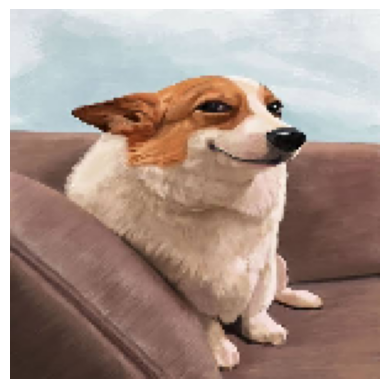

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Prediction: Dog
Confidence: 50.87 %


In [ ]:
#Step 12: Predict the Image
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = list(uploaded.keys())[0]
img = image.load_img(img_path, target_size=(150, 150))

plt.imshow(img)
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)
img_array = img_array/255.0
img_array = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_array)

score = prediction[0][0]

if score > 0.5:
  print("Prediction: Dog")
  print("Confidence:", round(score*100,2),"%")
else:
  print("Prediction: Cat")
  print("Confidence:", round((1-score)*100,2),"%")



In [ ]:
#Step 1: Convert the Keras Model to TensorFlow Lite
import tensorflow as tf

#Load the model
model = tf.keras.models.load_model("cat_dog_model.keras")

#Convert to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

##Save the model
with open("cat_dog_model.tflite","wb") as f:
  f.write(tflite_model)

print("IFLit model created successfully!")

##dowload the file
from google.colab import files
files.download("cat_dog_model.tflite")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Saved artifact at '/tmp/tmp53cfayoq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132924997087504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132924997084816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132924997081552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132924997084432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132924997083280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132924997087312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132924997086544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132924997085392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132924997081936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132924997087120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132924997082320

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>